# AB Test Experiment Report

**Team 13:** Shuxuan Xu(sx2412), Justine Dugger-Ades(gad2154), Yumeng Xu(yx2982), Shreaya Amalapurapu(sa4342)

**Github Repository:** [https://github.com/xsxsx-999/5243-project3-T13](https://github.com/xsxsx-999/5243-project3-T13)

**Lauched URL**:  [https://xsxsx-999.github.io/random-url-for-AB-test-5243/](https://xsxsx-999.github.io/random-url-for-AB-test-5243/)

## 1. Introduction & Research Question

Designed for STATGR5243, this project establishes a robust framework for conducting data-driven A/B testing. We developed an interactive data-cleaning platform via ShinyApps and instrumented it with Google Analytics for precise telemetry collection. The core of the project culminates in a full-scale A/B test, transitioning from experimental design to the statistical analysis of real-world user data to evaluate platform efficiency.

**Research Question:**
Does altering the navigation UI (tabs bars vs. next buttons) significantly impact a user's task efficiency (measured by time) and their subjective rating of the application? 

**Objective:**
By simulating a "mini-game" challenge environment, we aim to quantitatively identify which UI variant provides a smoother user experience, thereby informing the final design of the app.

## 2. Experimental Design & Methodology

### 2.1 Research Goal
This experiment was designed to evaluate whether different interface structures and instructional styles affect user experience and task completion in our data processing application. Specifically, we compared two distinct workflow navigation interfaces to examine their impact on clarity, speed, and the overall ease of completing data preparation steps.

### 2.2 Formal Hypotheses
The original premise was that UI structure influences usability and workflow efficiency. To test this rigorously, we defined the following statistical hypotheses:
* **Null Hypothesis ($H_0$):** There is no significant difference in workflow efficiency (measured by task completion time) and usability (measured by subjective rating) between the top-tab navigation layout and the linear sequential layout.
* **Alternative Hypothesis ($H_a$):** There is a significant difference in workflow efficiency and usability between the two UI navigation styles, indicating that one interface format is superior in facilitating data processing tasks.

### 2.3 Treatment Groups (UI Variants)
To test our hypotheses, we engineered two distinct versions of the application:
* **Version A (Top-Tab Navigation):** Utilized a top-tab layout where users could directly move between processing stages (e.g., data upload, cleaning, feature engineering, EDA, and export). This design afforded users higher flexibility, allowing them to freely revisit previous steps or jump between sections.

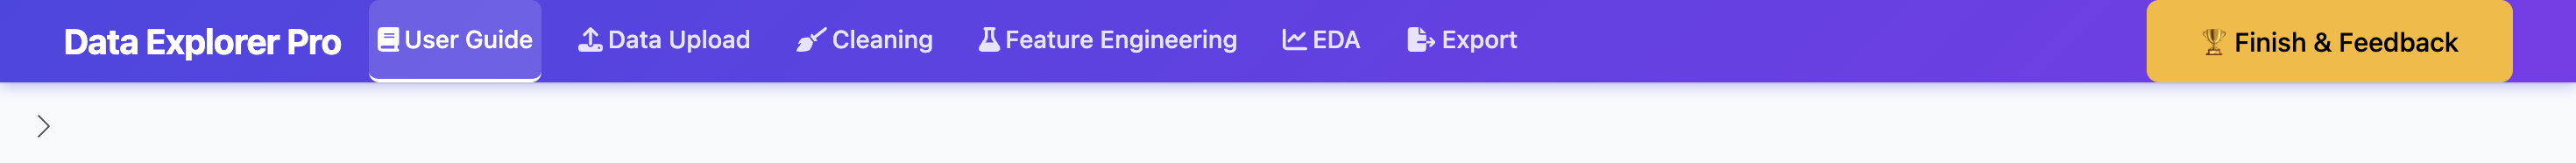

* **Version B (Linear Workflow):** Employed a sequential workflow design utilizing "Next" and "Back" buttons. This interface guided users through the data processing procedure in a highly structured, step-by-step manner.

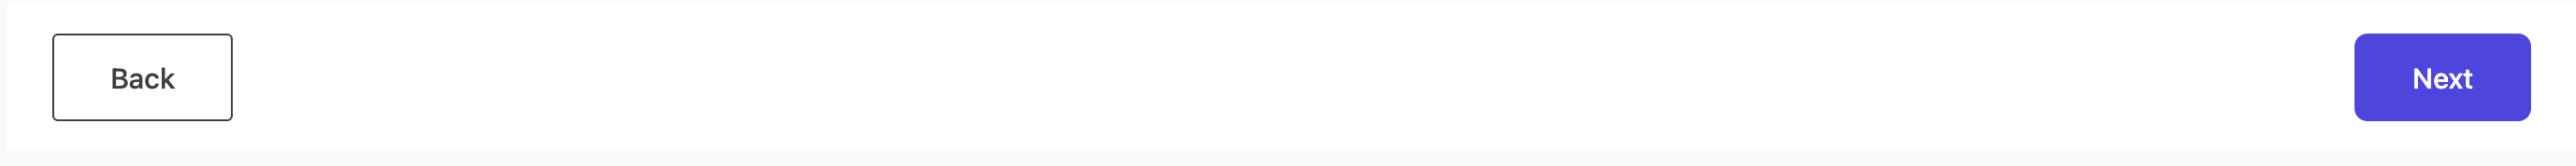

### 2.4 Methodology & Randomization Strategy
To ensure a robust controlled A/B test and preserve the internal validity of the experiment, we implemented the following routing and consistency protocols during the launch phase:
1. **Random Assignment & Routing:** A random assignment mechanism was introduced at the entry point of the system. A redirect URL dynamically routed users to one of the two separately deployed application versions, which were hosted in different repositories.
2. **Session Consistency (Local Storage):** To prevent users from accidentally switching between versions across sessions (or upon page refreshes), we utilized local storage. This ensured that each user remained locked into their initially assigned version.

This technical setup guaranteed three critical experimental conditions: each participant experienced only one interface condition, the assignment was strictly random, and user traffic was distributed as evenly as possible across both Version A and Version B.

## 3. Data Collection & Process

### 3.1 Custom Variables Documentation
To support the A/B test and evaluate how different workflow designs influence user behavior, original behavioral data was collected through custom Google Analytics (GA) event tracking embedded directly within the application.

#### 3.1.1 Event Tracking Architecture
Rather than relying on basic page views, we configured granular custom events to capture user interactions accurately. The tracking was built around three primary event types:
* `task_completed`: Triggered when a user successfully finishes a specific challenge.
* `session_completed`: Triggered when a user successfully finishes the entire data-processing pipeline.
* `session_abandoned`: Triggered if a user drops out before completing all tasks.

#### 3.1.2 Telemetry & Custom Variables
Each event captured a set of custom parameters mapped to GA custom dimensions and metrics. The selection of these variables was carefully designed to evaluate both workflow efficiency and user experience:

**a. Identifiers & Grouping:**
* **`ab_test_id` (UUID):** A unique identifier assigned to each user session. This ensures all actions performed by the same user are linked together, allowing us to reconstruct complete user journeys across events without collecting Personally Identifiable Information (PII).
* **`app_version`:** Indicates whether the user was assigned to Version A or Version B, which is essential for the fundamental A/B comparison.

**b. Task-Level Metrics:**
* **`task_id` & `time_spent_seconds`:** Records which specific step the user is on and the exact duration spent on it. This provides deep insights into usability, allowing us to pinpoint exact workflow bottlenecks and calculate efficiency.

**c. Session-Level Outcome Metrics:**
* **`tasks_completed` & `tasks_completed_at_dropout`:** Measures the total progression of the user and their dropout behavior. This Reflects overall workflow success and user engagement levels.

**d. Qualitative Metrics:**
* **`rating`:** Captures the user's subjective evaluation of the experience at the end of the session, which complements the quantitative behavioral data with subjective feedback, offering a comprehensive assessment of interface performance.

#### 3.1.3 Data Quality & Integrity
To ensure high-quality, reliable analysis, several data integrity protocols were implemented:
* **Mapping Documentation:** The mapping between code-level variables and their corresponding GA representations was carefully documented to prevent naming convention errors between the implementation and analytics platforms.
* **Controlled Collection Window:** A fixed data collection period was defined to avoid mixing experimental data with earlier beta-test data, with sufficient time allowed to account for standard GA data processing delays. This ensured the final dataset was well-structured and strictly aligned with the experimental design.

### 3.2 Collection & Processing

After exporting the raw tracking data from Google Analytics, we implemented a targeted data cleaning pipeline to ensure the reliability of our A/B testing metrics. The processing phase focused on three critical steps:

#### 3.3.1 Data Segmentation (Event-Based vs. User-Based)
To facilitate different levels of statistical analysis, the single raw dataset was deliberately split into two distinct, structured datasets:
* **Event-Based Dataset:** Contains granular, step-by-step tracking. Each row represents a specific action (e.g., completing a single task), allowing us to analyze micro-interactions, bottleneck tasks, and exact task durations.
* **User-Based Dataset:** Aggregates performance at the individual user level. Each row represents a single user's complete session, summarizing overarching metrics like total tasks completed, total time spent, and their final subjective rating.

#### 3.3.2 Filtering Invalid Sessions
During the initial data review, we identified tracking entries where the Session ID was missing or registered as `(not set)`. These anomalies were likely caused by accidental drops-ins or automated system pings generated when we had to switch application deployment URLs due to ShinyApps server usage limitations. To maintain strict user-level consistency and prevent noise, we filtered out these anomalies, extracting only valid rows with definitive session identifiers.

#### 3.3.3 Quality Thresholds
Excluded aggregated rows by enforcing `Total users == 1`, and applied a minimum time threshold to filter out accidental clicks or bot traffic.

#### 3.3.4 Final Dataset Output
Following the normalization pipeline, the fully cleaned dataset consisted of **421 valid event rows** representing **74 unique users**. The traffic distribution remained well-balanced and suitable for comparative analysis, with **38 users in Version A** and **36 users in Version B**.

## 4. Statistical Analysis & Interpretation

To evaluate the impact of the UI variants, we evaluated the null hypothesis ($H_0$: There is no significant difference between Version A and Version B, $\mu_A = \mu_B$) against the alternative hypothesis ($H_a$: $\mu_A \neq \mu_B$) at a significance level of $\alpha = 0.05$. 

To ensure the robustness of our analysis, we compute:
* **Welch’s t-test:** Two-sided p-value, normal approximation (to account for potential unequal variances between the two groups).
* **Bootstrap 95% CI:** To estimate the confidence interval for the mean difference (A − B).
* **Cohen’s d:** To measure the standardized effect size of the UI changes.

### 4.1 Key Metrics & Hypothesis Testing
Based on our decision helper outputs (evaluated at a typical $\alpha = 0.05$), we observed statistically significant differences in our core performance indicators:

* **Efficiency (Total Time):** We evaluated whether Version A's mean total time was less than Version B's (`A_mean < B_mean`). The result is **True** ($p = 0.008365$). Since $p < 0.05$, we reject $H_0$. Version A is significantly more efficient.
* **Usability (Rating):** We evaluated whether Version A's mean rating was greater than Version B's (`A_mean > B_mean`). The result is **True** ($p \approx 0.0$). Since $p < 0.05$, we reject $H_0$. Version A provides a significantly better user experience.

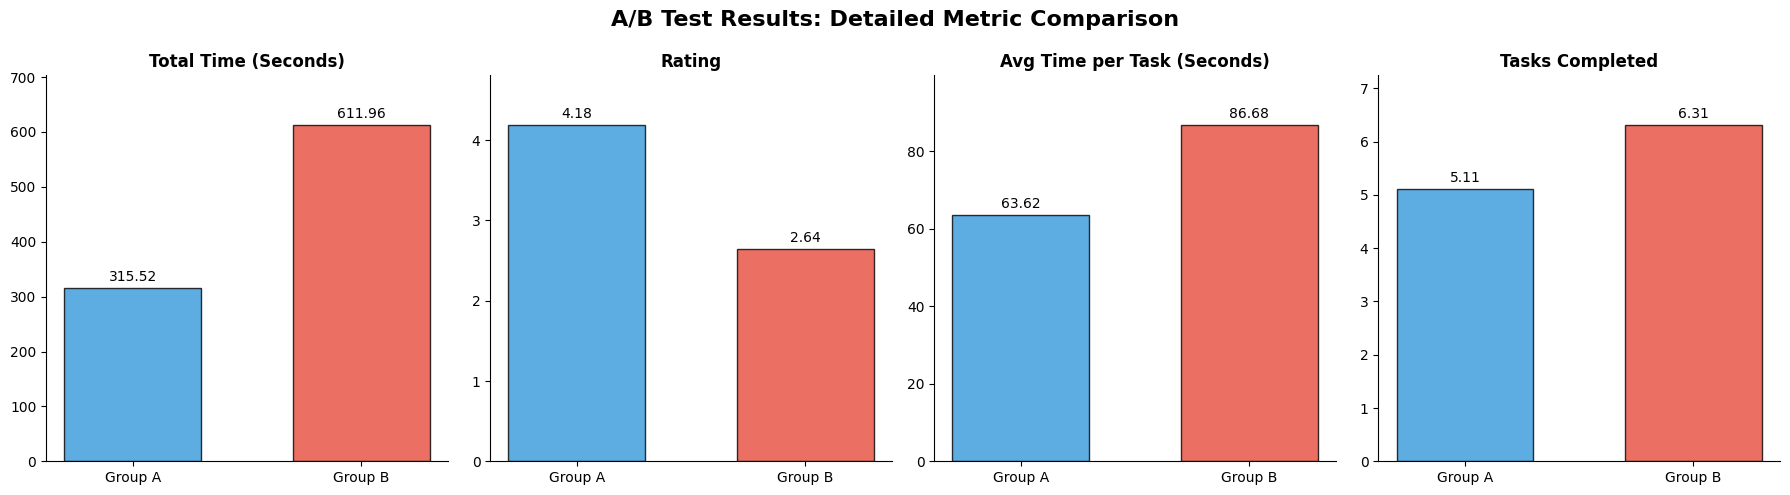

### 4.2 Per-Task Drill-Down Analysis(Complementary)
To understand exactly *where* Version B incurred such a massive usability penalty, we conducted a granular, task-by-task drill-down. We applied Welch's t-tests to the `time_spent_seconds` for each individual task (Task 1 through Task 11) to isolate specific workflow bottlenecks.

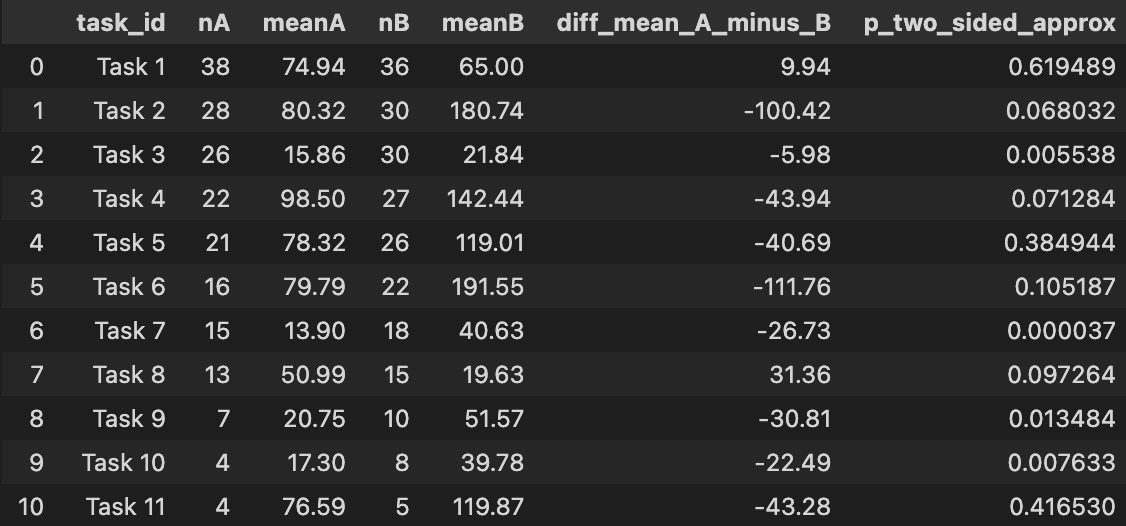

**Key Observations from the Task-Level Data:**
* **Pervasive Systemic Friction:** In 9 out of the 11 tasks, Version A's mean completion time was faster than Version B's (indicated by negative `diff_mean_A_minus_B` values). This proves that the sequential layout didn't just slow down one specific step; it introduced persistent friction across almost the entire workflow.
* **Statistically Significant Bottlenecks:** We observed statistically significant delays ($p < 0.05$) for users in Version B during **Task 3, Task 7, Task 9, and Task 10**. Task 7, in particular, showed an overwhelming disparity ($p = 0.000037$), taking users nearly three times as long in Version B (mean $\approx 40.63s$) compared to Version A (mean $\approx 13.90s$).
* **Severe Practical Delays:** Even in tasks where the $p$-value narrowly missed the strict 0.05 threshold (likely due to sample size drop-offs in later tasks and high variance), the practical time penalties were massive. For instance, Task 2 and Task 6 took Version B users roughly **100 seconds and 111 seconds longer** on average, respectively.

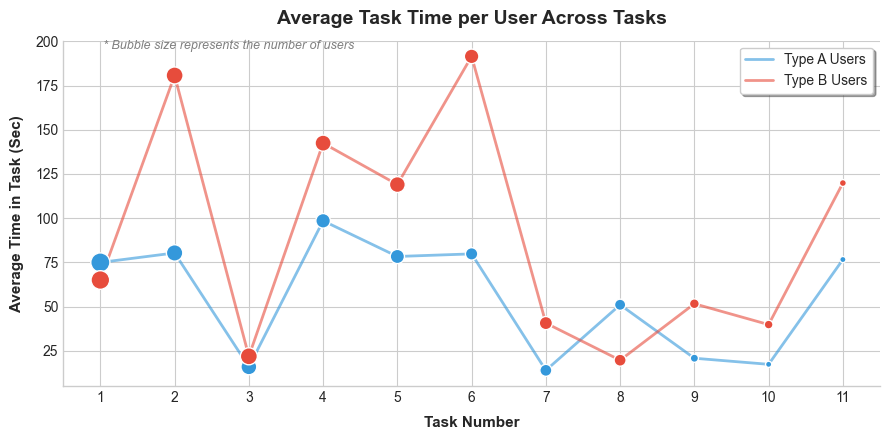



### 4.3 Interpretation & Conclusion
The statistical results provide convincing evidence that the interface layout fundamentally impacts user workflow, with Version A (Top-tab Navigation) demonstrating clear superiority. 

The rejection of our overarching null hypotheses (efficiency and usability) in Section 4.1, combined with the granular per-task breakdown in Section 4.2, paints a definitive picture: the rigid, sequential layout of Version B is fundamentally flawed for this application. Rather than a localized issue, Version B introduces pervasive friction that significantly slows users down on almost every individual data-cleaning step. 

By effectively doubling the total time spent and creating a frustrating user experience at the micro-task level, Version B failed to support an efficient data-cleaning process. In contrast, Version A’s flexible navigation empowered users to move through the pipeline with significantly higher micro- and macro-level efficiency, confirming that a non-linear, tab-based approach is far better suited for complex data tasks.

## 5. Challenges & Limitations

While the A/B test yielded statistically significant results and clear directional insights, we must acknowledge several limitations and challenges that contextualize our findings. Identifying these constraints is crucial for interpreting the data accurately and guiding future iterations of the application.

* **Sample Selection Bias & Baseline Expertise:** The participant pool for this experiment may not perfectly represent the ultimate target demographic of the application. There is likely an inherent variance in the users' baseline data literacy and familiarity with standard data-cleaning concepts. Because users possessed varying levels of prior knowledge, some may have been learning the data concepts on the fly rather than purely evaluating the UI navigation. This variance introduces a degree of noise into the `time_spent_seconds` metric.

* **Shared Usability Ambiguities (Task Instructions):** Based on qualitative feedback and overarching time metrics, we identified that some workflow friction was independent of the A/B UI layouts. Users reported that certain feature descriptions, tooltips, and task instructions within the app were vague or overly technical. This shared ambiguity likely inflated the baseline completion times across *both* Version A and Version B. It highlights that while navigation layout is critical, the underlying explanatory text requires a modification to improve overall clarity.

* **Uncontrolled Testing Environments & Telemetry Constraints:** Because the application was deployed via ShinyApps and tested remotely, we could not control for hardware and environmental differences (e.g., variations in screen sizes, use of trackpads vs. external mice, or network latency). These external factors can significantly impact the speed of completing interactive data tasks. 

## Team Member Contributions:

* **Shuxuan Xu (sx2412):** Led the development and setup of Version A, integrated Google Analytics (GA) for custom event tracking, and managed the overarching data collection process.

* **Shreaya Amalapurapu (sa4342):** Led the development and setup of Version B, ensuring the linear sequential navigation logic and UI constraints were properly implemented for the experiment.

* **Justine Dugger-Ades (gad2154):** Conducted the statistical analysis for the A/B test, including data cleaning, hypothesis testing, and the granular per-task bottleneck evaluation.

* **Yumeng Xu (yx2982):** Authored and structured the final analytical report, synthesizing the methodology, statistical findings, and comprehensive UX insights.